In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
path = r"E:\data_analytics_project\data\raw"

files = os.listdir(path)
files

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [4]:
customers = pd.read_csv(path + r"\olist_customers_dataset.csv")
geolocation = pd.read_csv(path + r"\olist_geolocation_dataset.csv")
orders = pd.read_csv(path + r"\olist_orders_dataset.csv")
order_items = pd.read_csv(path + r"\olist_order_items_dataset.csv")
payments = pd.read_csv(path + r"\olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + r"\olist_order_reviews_dataset.csv")
products = pd.read_csv(path + r"\olist_products_dataset.csv")
sellers = pd.read_csv(path + r"\olist_sellers_dataset.csv")
category_translation = pd.read_csv(path + r"\product_category_name_translation.csv")
order_payments = pd.read_csv(path + r"\olist_order_payments_dataset.csv")

In [12]:
tables = {
    "customers": customers,
    "geolocation": geolocation,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in tables.items():
    print(name, df.shape)

customers (99441, 5)
geolocation (1000163, 5)
orders (99441, 8)
order_items (112650, 7)
payments (103886, 5)
reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)
category_translation (71, 2)


In [13]:
for name, df in tables.items():
    print("\n---", name, "---")
    print(df.isnull().sum())


--- customers ---
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

--- geolocation ---
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

--- orders ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

--- order_items ---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

--- payments ---
order_id                0
payment_sequential      0
payment

In [14]:
for name, df in tables.items():
    print(name, "duplicates:", df.duplicated().sum())

customers duplicates: 0
geolocation duplicates: 261831
orders duplicates: 0
order_items duplicates: 0
payments duplicates: 0
reviews duplicates: 0
products duplicates: 0
sellers duplicates: 0
category_translation duplicates: 0


In [15]:
geolocation[geolocation.duplicated()].head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
72,1046,-23.545320,-46.644069,sao paulo,SP
79,1050,-23.549854,-46.643139,sao paulo,SP
80,1032,-23.540775,-46.635515,sao paulo,SP
82,1046,-23.546081,-46.644820,sao paulo,SP
86,1048,-23.547449,-46.640169,são paulo,SP


In [16]:
print("Total rows:", len(geolocation))
print("Unique ZIP codes:", geolocation["geolocation_zip_code_prefix"].nunique())

Total rows: 1000163
Unique ZIP codes: 19015


In [17]:
geolocation_clean = geolocation.drop_duplicates()

print("Before:", len(geolocation))
print("After:", len(geolocation_clean))

Before: 1000163
After: 738332


In [18]:
products[products["product_category_name"].isnull()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [19]:
products[products["product_category_name"].isnull()].isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [20]:
missing_products = products[
    products["product_category_name"].isnull()
]

missing_products["product_id"].isin(
    order_items["product_id"]
).sum()

np.int64(610)

In [21]:
missing_products = products[
    products["product_category_name"].isnull()
]

missing_product_orders = order_items[
    order_items["product_id"].isin(missing_products["product_id"])
]

print("Missing-category products sold:", missing_product_orders["product_id"].nunique())
print("Order items:", len(missing_product_orders))
print("Revenue:", missing_product_orders["price"].sum())

Missing-category products sold: 610
Order items: 1603
Revenue: 179535.28


In [22]:
missing_pct = products["product_category_name"].isnull().mean() * 100

print(f"Missing category: {missing_pct:.2f}%")

Missing category: 1.85%


In [23]:
products_clean = products.copy()

products_clean["product_category_name"] = (
    products_clean["product_category_name"].fillna("Unknown")
)

In [24]:
products_clean["product_category_name"].isnull().sum()

np.int64(0)

In [25]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [26]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [27]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [28]:
orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [29]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [30]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [31]:
order_items[order_items["price"] > 500]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.0,70.75
16,0009c9a17f916a706d71784483a5d643,1,3f27ac8e699df3d300ec4a5d8c5cf0b2,fcb5ace8bcc92f75707dc0f01a27d269,2018-05-02 09:31:53,639.0,11.34
39,0017afd5076e074a48f1f1a4c7bac9c5,1,fe59a1e006df3ac42bf0ceb876d70969,25c5c91f63607446a97b143d2d535d31,2017-04-24 22:25:19,809.1,44.29
158,006127b8b9a1681a982313ed7129c3c0,1,f819f0c84a64f02d3a5606ca95edd272,7d13fca15225358621be4086e1eb0964,2018-03-15 02:30:23,540.0,16.22
265,00ab9fa91aafa3d881164b0da48999aa,1,224037b21bfa8621e39c265513ee6594,ceaec5548eefc6e23e6607c5435102e7,2018-06-04 09:50:04,579.0,65.34
...,...,...,...,...,...,...,...
112449,ff85c3e4329457e83cb474799a257ccc,1,144266e1585320d057797a369596bb8b,850f4f8af5ea87287ac68de36e29107f,2018-01-24 16:57:45,899.0,17.50
112553,ffc2638415f3ce34e88641eef792c1fc,1,bc2d6310e5cbd60facb2f9c8d9471597,dc317f341ab0e22f39acbd9dbf9b4a1f,2017-06-12 13:41:58,629.0,67.08
112557,ffc49b9c9d666410e9ecdb0a3efadb9c,1,f96ff9b997681965689f78bef092fdd9,2a5b78b41cd05baeac8df54c6606b92c,2018-06-05 19:56:23,765.0,27.06
112571,ffd5e80bfdaf69504efd7562a3d522dd,1,bd67e67dcfcc53e712a29c215ec26de5,3d39fbf22a665714baf62fae36029e23,2017-08-28 09:46:08,584.9,16.65


In [32]:
result = order_items.groupby("seller_id")["price"].sum()
print(result)
result = result.reset_index()
print(result)

seller_id
0015a82c2db000af6aaaf3ae2ecb0532     2685.00
001cca7ae9ae17fb1caed9dfb1094831    25080.03
001e6ad469a905060d959994f1b41e4f      250.00
002100f778ceb8431b7a1020ff7ab48f     1234.50
003554e2dce176b5555353e4f3555ac8      120.00
                                      ...   
ffcfefa19b08742c5d315f2791395ee5       69.90
ffdd9f82b9a447f6f8d4b91554cc7dd3     2101.20
ffeee66ac5d5a62fe688b9d26f83f534     1839.86
fffd5413c0700ac820c7069d66d98c89     9062.30
ffff564a4f9085cd26170f4732393726     1426.30
Name: price, Length: 3095, dtype: float64
                             seller_id     price
0     0015a82c2db000af6aaaf3ae2ecb0532   2685.00
1     001cca7ae9ae17fb1caed9dfb1094831  25080.03
2     001e6ad469a905060d959994f1b41e4f    250.00
3     002100f778ceb8431b7a1020ff7ab48f   1234.50
4     003554e2dce176b5555353e4f3555ac8    120.00
...                                ...       ...
3090  ffcfefa19b08742c5d315f2791395ee5     69.90
3091  ffdd9f82b9a447f6f8d4b91554cc7dd3   2101.20
3092  ffeee6

In [33]:
category_revenue = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .assign(revenue=lambda df: df["price"] + df["freight_value"])
    .groupby("product_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

category_revenue

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241681.72
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
Name: revenue, dtype: float64

In [35]:
customer_spending = (
    orders
    .merge(
        order_payments[["order_id", "payment_value"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")["payment_value"]
    .sum()
    .reset_index()
)

customer_spending[
    customer_spending["payment_value"] > 10000
]

,customer_id,payment_value
8546,1617b1357756262bfa56ab541c47bc16,13664.08


In [ ]:
order_value = (
    orders
    .merge(
        order_payments[["order_id", "payment_value"]],
        on="order_id",
        how="left"
    )
    .groupby(["customer_id", "order_id"])["payment_value"]
    .sum()
    .reset_index()
)

customer_avg = (
    order_value
    .groupby("customer_id")["payment_value"]
    .mean()
    .reset_index(name="average_order_value")
)

In [46]:
top_seller=(
    order_items
    .merge(
        sellers[["seller_id"]],
        on="seller_id",
        how="left"
    ).assign(total_revenue=lambda df: df["price"] + df["freight_value"])
    .groupby("seller_id")["total_revenue"].sum().reset_index().sort_values(by="total_revenue", ascending=False).head(5)
)
top_seller


,seller_id,total_revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44
1013,53243585a1d6dc2643021fd1853d8905,235856.68
881,4a3ca9315b744ce9f8e9374361493884,235539.96
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73


In [52]:
#How many days did each delivered order take to reach the customer?
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [53]:
orders["delivery_days"].isnull().sum()

np.int64(2965)

In [59]:
#orders["late_delivery"] = np.where(orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"], 1, 0)
#orders["late_delivery"]
#or
orders["late_delivery"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
).astype(int)
orders["late_delivery"]

0        0
1        0
2        0
3        0
4        0
        ..
99436    0
99437    0
99438    0
99439    0
99440    0
Name: late_delivery, Length: 99441, dtype: int64

In [57]:
orders["late_delivery"] = np.where(
    orders["order_delivered_customer_date"].isna(),
    np.nan,
    np.where(
        orders["order_delivered_customer_date"] >
        orders["order_estimated_delivery_date"],
        1,
        0
    )
)

In [60]:
late_delivery_rate=orders["late_delivery"].mean()*100
late_delivery_rate

np.float64(7.870998883760219)

In [63]:
orders["late_delivery"].value_counts(normalize=True) * 100

late_delivery
0    92.129001
1     7.870999
Name: proportion, dtype: float64

In [72]:
category_revenue = (
    order_items
    .merge(
        products_clean[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    ).merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
    .assign(
        revenue=lambda df: df["price"] + df["freight_value"]
    )
    .groupby("product_category_name_english")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_revenue.head(10)

,product_category_name_english,revenue
43,health_beauty,1441248.07
70,watches_gifts,1305541.61
7,bed_bath_table,1241681.72
65,sports_leisure,1156656.48
15,computers_accessories,1059272.40
39,furniture_decor,902511.79
49,housewares,778397.77
20,cool_stuff,719329.95
5,auto,685384.32
42,garden_tools,584219.21


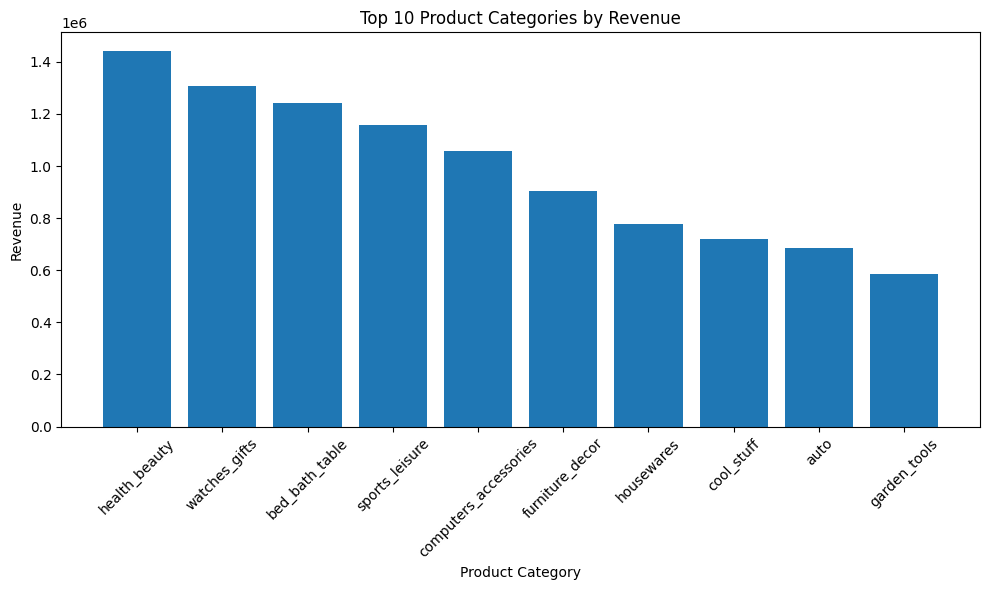

In [73]:
#Top 10 Product Categories by Revenue
#visualization
import matplotlib.pyplot as plt

top_categories = category_revenue.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_categories["product_category_name_english"],
    top_categories["revenue"]
)

plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.title("Top 10 Product Categories by Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

1.7.87% of delivered orders were late, indicating that delivery reliability is an area where logistics performance could be improved.
2.Orders took an average of 12.1 days to reach customers, while the median was 10 days, suggesting that a smaller number of significantly delayed orders are increasing the average delivery time.
3.Although only 1.85% of products had missing category information, these products were actively sold and generated approximately ₹179,535 in revenue. This indicates that incomplete product categorization could affect category-level sales analysis and reporting.
4.Revenue is concentrated among a small group of sellers, indicating that these sellers have a significant contribution to marketplace performance and may warrant closer attention for seller retention and partnership strategies.

In [84]:
order_revenue = (
    orders[["order_id", "order_purchase_timestamp"]]
    .merge(
        order_items[["order_id", "price", "freight_value"]],
        on="order_id",
        how="inner"
    )
    .assign(
        revenue=lambda df: df["price"] + df["freight_value"]
    )
)

monthly_revenue = (
    order_revenue
    .groupby(
        order_revenue["order_purchase_timestamp"].dt.to_period("M")
    )["revenue"]
    .sum()
    .reset_index()
)
monthly_revenue

,order_purchase_timestamp,revenue
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62
5,2017-03,432048.59
6,2017-04,412422.24
7,2017-05,586190.95
8,2017-06,502963.04
9,2017-07,584971.62


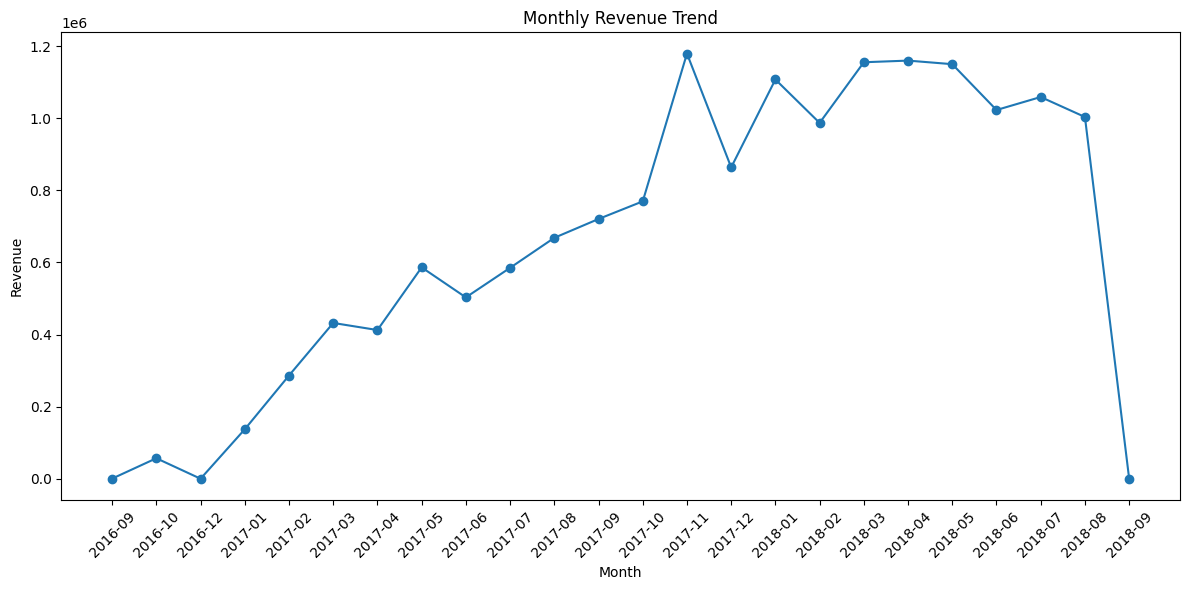

In [85]:
#monthly revenue trend visualization
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["order_purchase_timestamp"].astype(str),
    monthly_revenue["revenue"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

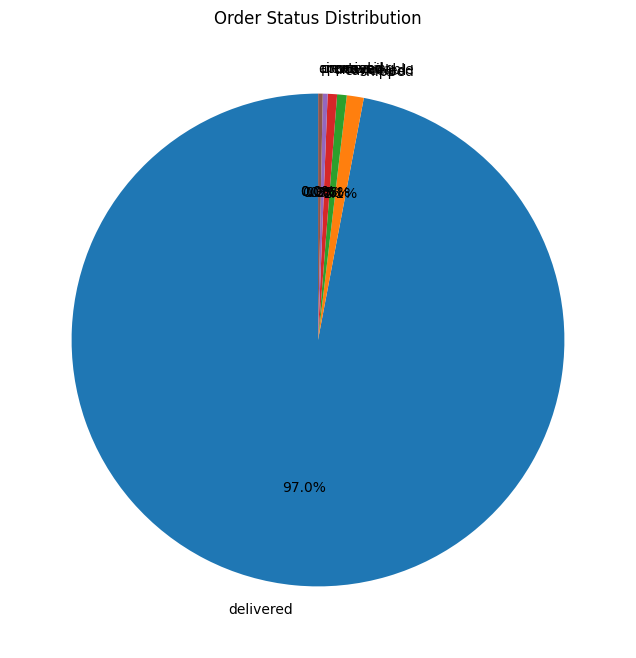

In [92]:
status_counts = orders["order_status"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Order Status Distribution")
plt.show()

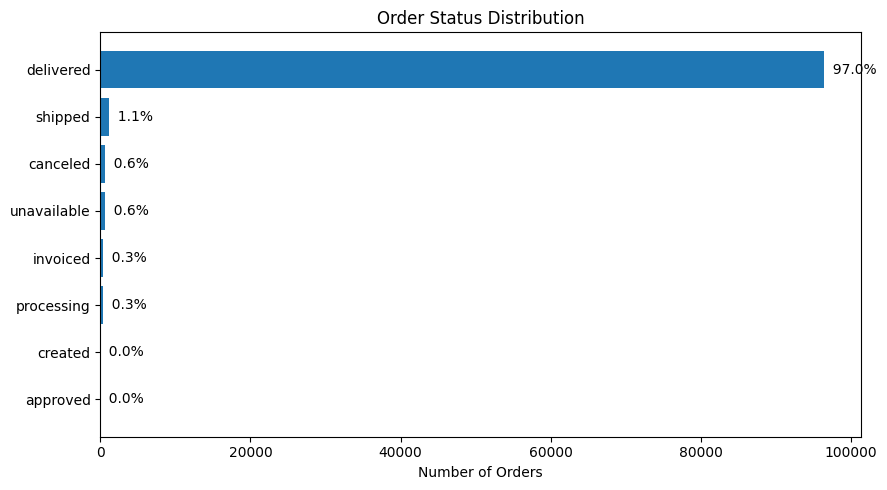

In [93]:
status_counts = orders["order_status"].value_counts()

status_percent = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    status_counts.index,
    status_counts.values
)

plt.xlabel("Number of Orders")
plt.ylabel("")
plt.title("Order Status Distribution")

for bar, percent in zip(bars, status_percent):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"  {percent:.1f}%",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [95]:
#Q.How are customers rating their orders?
review_counts = reviews["review_score"].value_counts().sort_index()

review_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

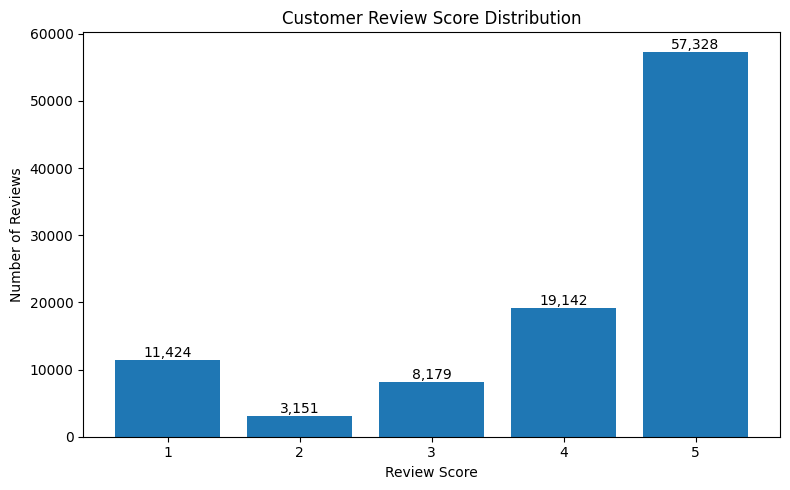

In [96]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    review_counts.index,
    review_counts.values
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.title("Customer Review Score Distribution")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [9]:
total_cust_spending = (
    customers.merge(
        orders[["customer_id", "order_id"]], on="customer_id", how="left"
    ).merge(order_payments[["order_id", "payment_value"]], on="order_id", how="left").groupby("customer_unique_id")["payment_value"].sum().reset_index(name="total_spending").sort_values(by="total_spending", ascending=False).assign(
        rank=lambda df: df["total_spending"]
            .rank(method="dense", ascending=False)
    ).head(10)
)
total_cust_spending


,customer_unique_id,total_spending,rank
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08,1.0
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02,2.0
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63,3.0
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,4.0
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31,5.0
26205,459bef486812aa25204be022145caa62,6922.21,6.0
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,7.0
24121,4007669dec559734d6f53e029e360987,6081.54,8.0
35070,5d0a2980b292d049061542014e8960bf,4809.44,9.0
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,10.0


In [15]:
top_seller = (
    order_items
    .assign(
        total_revenue=lambda df: df["price"] + df["freight_value"]
    )
    .groupby("seller_id")
    .agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_revenue", "sum")
    )
    .query("order_count >= 100")
    .sort_values("total_revenue", ascending=False)
    .head(5)
    .reset_index()
)
top_seller

,seller_id,order_count,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,249640.70
1,7c67e1448b00f6e969d365cea6b010ab,982,239536.44
2,53243585a1d6dc2643021fd1853d8905,358,235856.68
3,4a3ca9315b744ce9f8e9374361493884,1806,235539.96
4,fa1c13f2614d7b5c4749cbc52fecda94,585,204084.73


In [ ]:
repeat = (
    customers
    .merge(
        orders[["customer_id", "order_purchase_timestamp"]],
        on="customer_id",
        how="left"
    )
    .assign(
        purchase_date=lambda df: pd.to_datetime(
            df["order_purchase_timestamp"]
        ).dt.date
    )
    .groupby("customer_unique_id")
    .agg(
        purchase_days=("purchase_date", "nunique")
    )
    .reset_index()
    .query("purchase_days >= 3")
    .sort_values("purchase_days", ascending=False)
)
repeat

,customer_unique_id,purchase_days
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
76082,ca77025e7201e3b30c44b472ff346268,7
37797,6469f99c1f9dfae7733b25662e7f1782,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
...,...,...
93402,f8bc1d81f395f6239a2a5ab1b9edf1ab,3
95160,fd8ccc89be43894d2553494c71a61fd8,3
95463,fe59d5878cd80080edbd29b5a0a4e1cf,3
95784,ff36be26206fffe1eb37afd54c70e18b,3


In [28]:
product_category_revenue = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .assign(
        revenue=lambda df: df["price"] + df["freight_value"]
    )
    .groupby(
        ["product_category_name", "product_id"]
    )
    .agg(
        revenue=("revenue", "sum")
    )
    .reset_index()
    .assign(
        category_total=lambda df:
            df.groupby("product_category_name")["revenue"]
              .transform("sum")
    )
    .assign(
        category_revenue_pct=lambda df:
            df["revenue"] / df["category_total"] * 100
    )
)
product_category_revenue

,product_category_name,product_id,revenue,category_total,category_revenue_pct
0,agro_industria_e_comercio,018ca97302e4293050cc41413194bb19,99.95,78374.07,0.127529
1,agro_industria_e_comercio,026f43af35e7951067097527d5c31bcc,422.48,78374.07,0.539056
2,agro_industria_e_comercio,07f01b6fcacc1b187a71e5074199db2d,86.99,78374.07,0.110993
3,agro_industria_e_comercio,0a0adf0de1769b2970f3096d0b5abfb7,87.61,78374.07,0.111784
4,agro_industria_e_comercio,0a27862bbf658a5b8cf655761bc5c72d,118.62,78374.07,0.151351
...,...,...,...,...,...
32336,utilidades_domesticas,ff95ac47246ef13e48712ea1ff8df0d9,169.04,778397.77,0.021716
32337,utilidades_domesticas,ffaaddefb271481c66d4bd79844ecdae,71.47,778397.77,0.009182
32338,utilidades_domesticas,ffbc83054b3741a8d67fc59d9cf9d42d,56.53,778397.77,0.007262
32339,utilidades_domesticas,ffc88104d219c1b767d566fd93653dd2,48.93,778397.77,0.006286
